In [49]:
import pandas as pd
from pathlib import Path
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle

In [29]:
# Load in the cleaned good and bad start datasets.

df = pd.read_csv(Path("../Data/Cleaned/all_selected_starts.csv"))
good_df = pd.read_csv(Path("../Data/Cleaned/good_starts.csv"))
bad_df = pd.read_csv(Path("../Data/Cleaned/bad_starts.csv"))

In [30]:
# Check the size of each dataset.

good_df.shape, bad_df.shape

((495, 41), (421, 41))

# Pitch Usage

The first step is to compare how Webb used each pitch during his selected good and bad starts. For each pitch type, I calculate its usage as a percentage of all pitches thrown and compare the differences between the two groups.

In [31]:
# Calculate pitch usage for the good and bad start samples.

good_usage = (
    good_df["pitch_name"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

bad_usage = (
    bad_df["pitch_name"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

usage_summary = pd.DataFrame({
    "Good Usage (%)": good_usage,
    "Bad Usage (%)": bad_usage
}).fillna(0)

usage_summary["Difference (%)"] = (
    usage_summary["Good Usage (%)"] - usage_summary["Bad Usage (%)"]
).round(2)

usage_summary

,Good Usage (%),Bad Usage (%),Difference (%)
pitch_name,,,
4-Seam Fastball,16.57,10.93,5.64
Changeup,28.69,20.19,8.50
Cutter,12.73,13.06,-0.33
Sinker,23.23,37.29,-14.06
Sweeper,18.79,18.53,0.26


# Pitch Effectiveness

The next step is to compare how effective each pitch was during Webb's selected good and bad starts. This section looks beyond pitch usage and focuses on how well each pitch actually performed.

In [66]:
# Calculate whiff rate for each pitch type.

whiff_descriptions = [
    "swinging_strike",
    "swinging_strike_blocked"
]

good_whiff = (
    good_df.assign(whiff=good_df["description"].isin(whiff_descriptions))
    .groupby("pitch_name")["whiff"]
    .mean()
    .mul(100)
    .round(2)
)

bad_whiff = (
    bad_df.assign(whiff=bad_df["description"].isin(whiff_descriptions))
    .groupby("pitch_name")["whiff"]
    .mean()
    .mul(100)
    .round(2)
)

whiff_summary = pd.DataFrame({
    "Good Whiff (%)": good_whiff,
    "Bad Whiff (%)": bad_whiff
})

whiff_summary["Difference (%)"] = (
    whiff_summary["Good Whiff (%)"] - whiff_summary["Bad Whiff (%)"]
).round(2)

whiff_summary

,Good Whiff (%),Bad Whiff (%),Difference (%)
pitch_name,,,
4-Seam Fastball,7.32,13.04,-5.72
Changeup,14.08,16.47,-2.39
Cutter,7.94,10.91,-2.97
Sinker,2.61,4.46,-1.85
Sweeper,6.45,1.28,5.17


In [33]:
# Define the Statcast outcomes needed to calculate AVG, OBP, SLG, OPS, and wOBA.

hit_events = {
    "single",
    "double",
    "triple",
    "home_run"
}

at_bat_events = {
    "single",
    "double",
    "triple",
    "home_run",
    "field_out",
    "force_out",
    "grounded_into_double_play",
    "strikeout",
    "fielders_choice",
    "double_play"
}

walk_events = {
    "walk"
}

hbp_events = {
    "hit_by_pitch"
}

total_bases = {
    "single": 1,
    "double": 2,
    "triple": 3,
    "home_run": 4
}

In [34]:
# Calculate actual AVG, OBP, SLG, OPS, and wOBA for each pitch type.

def calculate_pitch_outcomes(data):
    """Calculate outcome metrics from plate appearances ending on each pitch type."""

    ending_pitches = data[
        data["events"].notna() &
        (data["events"] != "truncated_pa")
    ].copy()

    ending_pitches["hit"] = ending_pitches["events"].isin(hit_events)
    ending_pitches["official_at_bat"] = ending_pitches["events"].isin(at_bat_events)
    ending_pitches["walk"] = ending_pitches["events"].isin(walk_events)
    ending_pitches["hit_by_pitch"] = ending_pitches["events"].isin(hbp_events)
    ending_pitches["total_bases"] = (
        ending_pitches["events"]
        .map(total_bases)
        .fillna(0)
    )

    pitch_outcomes = ending_pitches.groupby("pitch_name").agg(
        Plate_Appearances=("events", "count"),
        Hits=("hit", "sum"),
        At_Bats=("official_at_bat", "sum"),
        Walks=("walk", "sum"),
        Hit_By_Pitch=("hit_by_pitch", "sum"),
        Total_Bases=("total_bases", "sum"),
        wOBA_Value=("woba_value", "sum"),
        wOBA_Denom=("woba_denom", "sum")
    )

    pitch_outcomes["AVG"] = (
        pitch_outcomes["Hits"] / pitch_outcomes["At_Bats"]
    )

    pitch_outcomes["OBP"] = (
        (
            pitch_outcomes["Hits"] +
            pitch_outcomes["Walks"] +
            pitch_outcomes["Hit_By_Pitch"]
        ) /
        (
            pitch_outcomes["At_Bats"] +
            pitch_outcomes["Walks"] +
            pitch_outcomes["Hit_By_Pitch"]
        )
    )

    pitch_outcomes["SLG"] = (
        pitch_outcomes["Total_Bases"] / pitch_outcomes["At_Bats"]
    )

    pitch_outcomes["OPS"] = (
        pitch_outcomes["OBP"] + pitch_outcomes["SLG"]
    )

    pitch_outcomes["wOBA"] = (
        pitch_outcomes["wOBA_Value"] / pitch_outcomes["wOBA_Denom"]
    )

    metric_columns = ["AVG", "OBP", "SLG", "OPS", "wOBA"]
    pitch_outcomes[metric_columns] = pitch_outcomes[metric_columns].round(3)

    return pitch_outcomes[
        [
            "Plate_Appearances",
            "Hits",
            "At_Bats",
            "Walks",
            "Hit_By_Pitch",
            "AVG",
            "OBP",
            "SLG",
            "OPS",
            "wOBA"
        ]
    ]

In [35]:
# Calculate pitch outcomes for the good and bad starts.

good_outcomes = calculate_pitch_outcomes(good_df)
bad_outcomes = calculate_pitch_outcomes(bad_df)

In [36]:
# Combine the good and bad results into one comparison table.

outcomes_summary = good_outcomes.add_prefix("Good_").join(
    bad_outcomes.add_prefix("Bad_"),
    how="outer"
)

outcomes_summary["AVG_Difference"] = (
    outcomes_summary["Good_AVG"] - outcomes_summary["Bad_AVG"]
).round(3)

outcomes_summary["OPS_Difference"] = (
    outcomes_summary["Good_OPS"] - outcomes_summary["Bad_OPS"]
).round(3)

outcomes_summary["wOBA_Difference"] = (
    outcomes_summary["Good_wOBA"] - outcomes_summary["Bad_wOBA"]
).round(3)

outcomes_summary

,Good_Plate_Appearances,Good_Hits,Good_At_Bats,Good_Walks,Good_Hit_By_Pitch,Good_AVG,Good_OBP,Good_SLG,Good_OPS,Good_wOBA,Bad_Plate_Appearances,Bad_Hits,Bad_At_Bats,Bad_Walks,Bad_Hit_By_Pitch,Bad_AVG,Bad_OBP,Bad_SLG,Bad_OPS,Bad_wOBA,AVG_Difference,OPS_Difference,wOBA_Difference
pitch_name,,,,,,,,,,,,,,,,,,,,,,,
4-Seam Fastball,23,1,21,2,0,0.048,0.130,0.048,0.178,0.100,11,3,11,0,0,0.273,0.273,0.636,0.909,0.377,-0.225,-0.731,-0.277
Changeup,36,6,35,1,0,0.171,0.194,0.200,0.394,0.179,31,11,31,0,0,0.355,0.355,0.484,0.839,0.407,-0.184,-0.445,-0.228
Cutter,13,3,12,0,0,0.250,0.250,0.417,0.667,0.300,11,6,11,0,0,0.545,0.545,0.909,1.455,0.623,-0.295,-0.788,-0.323
Sinker,37,6,36,1,0,0.167,0.189,0.250,0.439,0.195,52,15,45,5,2,0.333,0.423,0.556,0.979,0.423,-0.166,-0.540,-0.228
Sweeper,24,3,24,0,0,0.125,0.125,0.125,0.250,0.112,15,4,12,3,0,0.333,0.467,0.667,1.133,0.477,-0.208,-0.883,-0.365


# Pitch Characteristics

In [38]:
# Calculate average velocity for each pitch type.

good_velocity = (
    good_df.groupby("pitch_name")["release_speed"]
    .mean()
    .round(2)
)

bad_velocity = (
    bad_df.groupby("pitch_name")["release_speed"]
    .mean()
    .round(2)
)

velocity_summary = pd.DataFrame({
    "Good Velocity (mph)": good_velocity,
    "Bad Velocity (mph)": bad_velocity
})

velocity_summary["Difference (mph)"] = (
    velocity_summary["Good Velocity (mph)"] -
    velocity_summary["Bad Velocity (mph)"]
).round(2)

velocity_summary

,Good Velocity (mph),Bad Velocity (mph),Difference (mph)
pitch_name,,,
4-Seam Fastball,92.36,92.45,-0.09
Changeup,86.15,85.96,0.19
Cutter,89.55,89.90,-0.35
Sinker,91.89,92.22,-0.33
Sweeper,83.86,84.32,-0.46


In [39]:
# Calculate average horizontal and vertical break in inches for each pitch type.

good_break = (
    good_df.groupby("pitch_name")[["pfx_x", "pfx_z"]]
    .mean() * 12
).round(2)

bad_break = (
    bad_df.groupby("pitch_name")[["pfx_x", "pfx_z"]]
    .mean() * 12
).round(2)

break_summary = pd.DataFrame({
    "Good Horizontal Break (in)": good_break["pfx_x"],
    "Bad Horizontal Break (in)": bad_break["pfx_x"],
    "Good Vertical Break (in)": good_break["pfx_z"],
    "Bad Vertical Break (in)": bad_break["pfx_z"]
})

break_summary["Horizontal Difference (in)"] = (
    break_summary["Good Horizontal Break (in)"] -
    break_summary["Bad Horizontal Break (in)"]
).round(2)

break_summary["Vertical Difference (in)"] = (
    break_summary["Good Vertical Break (in)"] -
    break_summary["Bad Vertical Break (in)"]
).round(2)

break_summary

,Good Horizontal Break (in),Bad Horizontal Break (in),Good Vertical Break (in),Bad Vertical Break (in),Horizontal Difference (in),Vertical Difference (in)
pitch_name,,,,,,
4-Seam Fastball,-7.25,-7.65,10.30,9.08,0.40,1.22
Changeup,-10.75,-9.42,-5.17,-5.57,-1.33,0.40
Cutter,-0.69,-0.16,7.16,6.35,-0.53,0.81
Sinker,-15.02,-15.72,-0.03,1.00,0.70,-1.03
Sweeper,15.30,14.89,1.34,0.14,0.41,1.20


In [40]:
# Compare release point characteristics for each pitch type.

good_release = (
    good_df.groupby("pitch_name")[
        ["release_pos_z", "release_pos_x", "release_extension"]
    ]
    .mean()
    .round(2)
)

bad_release = (
    bad_df.groupby("pitch_name")[
        ["release_pos_z", "release_pos_x", "release_extension"]
    ]
    .mean()
    .round(2)
)

release_summary = pd.DataFrame({
    "Good Release Height (ft)": good_release["release_pos_z"],
    "Bad Release Height (ft)": bad_release["release_pos_z"],
    "Good Release Side (ft)": good_release["release_pos_x"],
    "Bad Release Side (ft)": bad_release["release_pos_x"],
    "Good Extension (ft)": good_release["release_extension"],
    "Bad Extension (ft)": bad_release["release_extension"]
})

release_summary["Height Difference (ft)"] = (
    release_summary["Good Release Height (ft)"] -
    release_summary["Bad Release Height (ft)"]
).round(2)

release_summary["Side Difference (ft)"] = (
    release_summary["Good Release Side (ft)"] -
    release_summary["Bad Release Side (ft)"]
).round(2)

release_summary["Extension Difference (ft)"] = (
    release_summary["Good Extension (ft)"] -
    release_summary["Bad Extension (ft)"]
).round(2)

release_summary

,Good Release Height (ft),Bad Release Height (ft),Good Release Side (ft),Bad Release Side (ft),Good Extension (ft),Bad Extension (ft),Height Difference (ft),Side Difference (ft),Extension Difference (ft)
pitch_name,,,,,,,,,
4-Seam Fastball,5.06,5.02,-1.73,-1.67,6.83,6.90,0.04,-0.06,-0.07
Changeup,4.75,4.75,-1.94,-1.96,6.78,6.89,0.00,0.02,-0.11
Cutter,5.00,4.96,-1.86,-1.79,6.77,6.85,0.04,-0.07,-0.08
Sinker,5.02,5.00,-1.82,-1.82,6.86,6.80,0.02,0.00,0.06
Sweeper,4.83,4.84,-2.05,-2.07,6.67,6.63,-0.01,0.02,0.04


In [64]:
# Compare average spin rate and standard deviation by pitch type.

def calculate_spin_rate(data):
    """Calculate average spin rate and standard deviation for each pitch type."""

    spin = (
        data.groupby("pitch_name")["release_spin_rate"]
        .agg(["mean", "std"])
        .round(0)
        .rename(columns={
            "mean": "Spin Rate (RPM)",
            "std": "SD (RPM)"
        })
    )

    return spin


good_spin = calculate_spin_rate(good_df)
bad_spin = calculate_spin_rate(bad_df)

spin_summary = good_spin.add_prefix("Good ").join(
    bad_spin.add_prefix("Bad "),
    how="outer"
)

spin_summary["Difference (RPM)"] = (
    spin_summary["Good Spin Rate (RPM)"] -
    spin_summary["Bad Spin Rate (RPM)"]
).round(0)

spin_summary

,Good Spin Rate (RPM),Good SD (RPM),Bad Spin Rate (RPM),Bad SD (RPM),Difference (RPM)
pitch_name,,,,,
4-Seam Fastball,2094.0,68.0,2061.0,60.0,33.0
Changeup,1496.0,69.0,1458.0,85.0,38.0
Cutter,2328.0,73.0,2285.0,100.0,43.0
Sinker,1973.0,203.0,1943.0,87.0,30.0
Sweeper,2640.0,82.0,2581.0,97.0,59.0


# Pitch Location

In [61]:
# Build a 21-zone location heat map for each pitch type.

CORNER_BOXES = {
    (0, 0),
    (0, 4),
    (4, 0),
    (4, 4)
}

ZONE_LEFT = -0.83
ZONE_RIGHT = 0.83
ZONE_WIDTH = ZONE_RIGHT - ZONE_LEFT


def assign_21_zone(row):
    """Assign a pitch to one of 21 boxes around the batter-specific strike zone."""

    x = row["plate_x"]
    z = row["plate_z"]
    zone_bottom = row["sz_bot"]
    zone_top = row["sz_top"]

    if pd.isna(x) or pd.isna(z) or pd.isna(zone_bottom) or pd.isna(zone_top):
        return None

    cell_width = ZONE_WIDTH / 3
    cell_height = (zone_top - zone_bottom) / 3

    x_edges = [
        -np.inf,
        ZONE_LEFT,
        ZONE_LEFT + cell_width,
        ZONE_LEFT + 2 * cell_width,
        ZONE_RIGHT,
        np.inf
    ]

    z_edges = [
        -np.inf,
        zone_bottom,
        zone_bottom + cell_height,
        zone_bottom + 2 * cell_height,
        zone_top,
        np.inf
    ]

    column = np.digitize(x, x_edges) - 1
    vertical_bin = np.digitize(z, z_edges) - 1

    # Reverse the order so higher pitches appear at the top.
    row_number = 4 - vertical_bin

    if (row_number, column) in CORNER_BOXES:
        return None

    return row_number, column

In [62]:
# Plot one 21-zone heat map.

def plot_21_zone_heatmap(data, pitch_name, ax, title):
    """Plot pitch counts relative to the total-pitches-divided-by-nine baseline."""

    pitch_data = data[data["pitch_name"] == pitch_name].copy()

    pitch_data["location_box"] = pitch_data.apply(
        assign_21_zone,
        axis=1
    )

    counts = np.zeros((5, 5))

    for row_number, column in pitch_data["location_box"].dropna():
        counts[row_number, column] += 1

    for row_number, column in CORNER_BOXES:
        counts[row_number, column] = np.nan

    total_pitches = len(pitch_data)
    baseline = total_pitches / 9
    highest_count = np.nanmax(counts)

    color_scale = TwoSlopeNorm(
        vmin=0,
        vcenter=baseline,
        vmax=max(highest_count, baseline + 1)
    )

    ax.imshow(
        counts,
        cmap="coolwarm",
        norm=color_scale
    )

    for row_number in range(5):
        for column in range(5):
            if not np.isnan(counts[row_number, column]):
                ax.text(
                    column,
                    row_number,
                    int(counts[row_number, column]),
                    ha="center",
                    va="center",
                    fontweight="bold"
                )

    # Outline the 3x3 strike zone.
    ax.add_patch(
        Rectangle(
            (0.5, 0.5),
            3,
            3,
            fill=False,
            linewidth=3,
            edgecolor="black"
        )
    )

    ax.set_title(
        f"{title}\nBaseline: {baseline:.1f} pitches"
    )

    ax.set_xticks([])
    ax.set_yticks([])

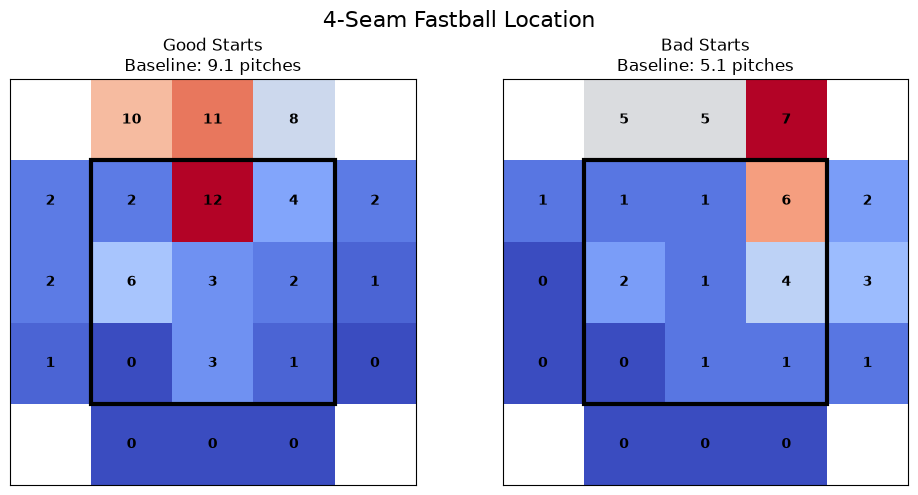

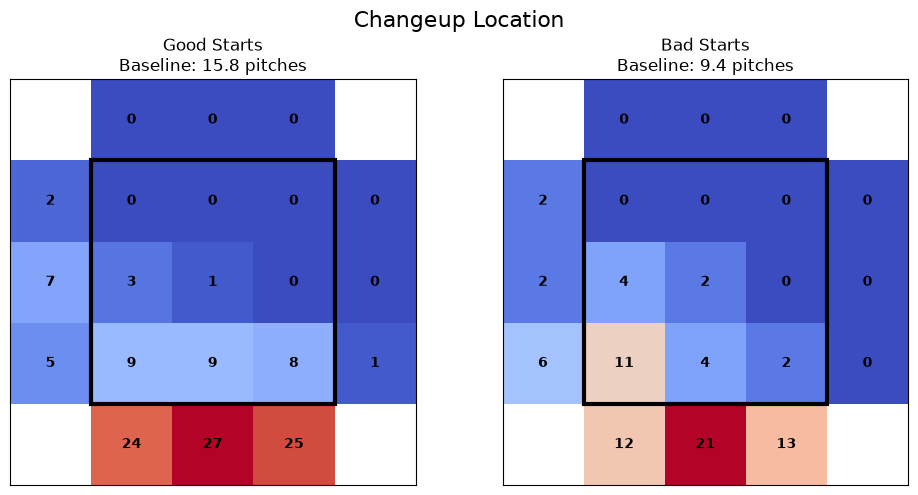

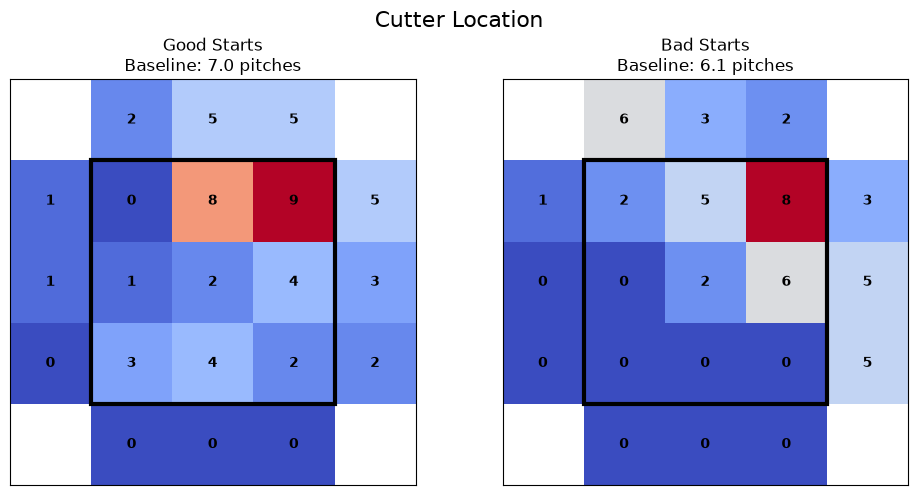

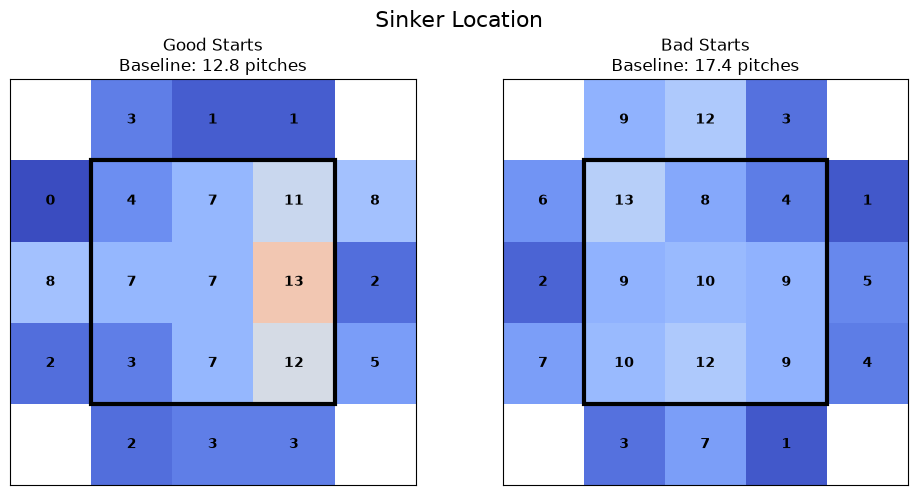

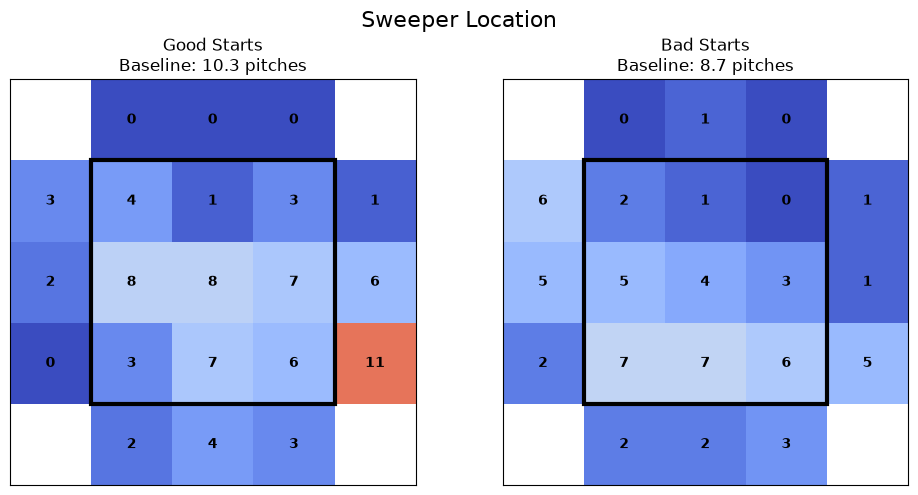

In [63]:
# Create side-by-side good and bad heat maps for every pitch type.

pitch_types = sorted(
    set(good_df["pitch_name"].dropna()) |
    set(bad_df["pitch_name"].dropna())
)

for pitch_name in pitch_types:
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10, 5)
    )

    plot_21_zone_heatmap(
        good_df,
        pitch_name,
        axes[0],
        "Good Starts"
    )

    plot_21_zone_heatmap(
        bad_df,
        pitch_name,
        axes[1],
        "Bad Starts"
    )

    fig.suptitle(
        f"{pitch_name} Location",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

# Pitch Counts

In [65]:
# Count the unique counts reached in each plate appearance.

def count_occurrences_by_count(data):
    """Count how many plate appearances reached each count."""

    counts = (
        data
        .assign(count=data["balls"].astype(str) + "-" + data["strikes"].astype(str))
        .drop_duplicates(subset=["game_date", "inning", "at_bat_number", "count"])
        .groupby("count")
        .size()
    )

    count_order = [
        "1-0", "0-1",
        "2-0", "1-1", "0-2",
        "3-0", "2-1", "1-2",
        "3-1", "2-2",
        "3-2"
    ]

    counts = counts.reindex(count_order, fill_value=0)

    total_plate_appearances = (
        data[["game_date", "inning", "at_bat_number"]]
        .drop_duplicates()
        .shape[0]
    )

    percentages = (
        counts / total_plate_appearances * 100
    ).round(1)

    return pd.DataFrame({
        "Count": counts,
        "Percentage": percentages
    })


good_counts = count_occurrences_by_count(good_df)
bad_counts = count_occurrences_by_count(bad_df)

count_summary = pd.DataFrame({
    "Good Count": good_counts["Count"],
    "Good %": good_counts["Percentage"],
    "Bad Count": bad_counts["Count"],
    "Bad %": bad_counts["Percentage"]
})

count_summary

,Good Count,Good %,Bad Count,Bad %
count,,,,
1-0,47,35.1,44,36.7
0-1,65,48.5,54,45.0
2-0,10,7.5,13,10.8
1-1,52,38.8,36,30.0
0-2,27,20.1,23,19.2
3-0,3,2.2,1,0.8
2-1,23,17.2,23,19.2
1-2,39,29.1,31,25.8
3-1,7,5.2,9,7.5
